# 05 — Correlation Analysis & Feature Selection
**Hotel Booking Demand Dataset**

This notebook computes the full correlation matrix for numerical features,
identifies the features most predictive of cancellation, detects multicollinearity,
and produces a feature selection plan for the Week 3 ML model.

**Objectives:**
- Map pairwise correlations across all numerical features
- Rank features by correlation with `is_canceled`
- Flag any feature pairs with |r| > 0.85 (multicollinearity risk)
- Decide which features to retain, drop, or engineer before modelling


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})


In [2]:
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Null values: {df.isnull().sum().sum()}")


Loaded: 85,598 rows x 36 columns
Null values: 0


---
## 1 — Select Relevant Numerical Columns

In [3]:
# All numerical columns in the dataset
all_num = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude date-component columns — they're already encoded in arrival_date
# and would add redundant signal (week number, day of month, year)
exclude_cols = ["arrival_date_year", "arrival_date_week_number",
                "arrival_date_day_of_month"]

analysis_cols = [c for c in all_num if c not in exclude_cols]

print(f"Total numerical columns   : {len(all_num)}")
print(f"Excluded (date components): {len(exclude_cols)}")
print(f"Selected for analysis     : {len(analysis_cols)}")
print()
print("Selected columns:")
for i, col in enumerate(analysis_cols, 1):
    print(f"  {i:>2}. {col}")


Total numerical columns   : 23
Excluded (date components): 3
Selected for analysis     : 20

Selected columns:
   1. is_canceled
   2. lead_time
   3. stays_in_weekend_nights
   4. stays_in_week_nights
   5. adults
   6. children
   7. babies
   8. is_repeated_guest
   9. previous_cancellations
  10. previous_bookings_not_canceled
  11. booking_changes
  12. agent
  13. company
  14. days_in_waiting_list
  15. adr
  16. required_car_parking_spaces
  17. total_of_special_requests
  18. total_nights
  19. total_guests
  20. revenue_per_booking


---
## 2 — Compute Correlation Matrix

In [4]:
corr_matrix = df[analysis_cols].corr()

print(f"Correlation matrix shape: {corr_matrix.shape}")
print()
print("Preview — first 5x5 block:")
print(corr_matrix.iloc[:5, :5].round(3).to_string())


Correlation matrix shape: (20, 20)

Preview — first 5x5 block:
                         is_canceled  lead_time  stays_in_weekend_nights  stays_in_week_nights  adults
is_canceled                    1.000      0.183                    0.056                 0.079   0.083
lead_time                      0.183      1.000                    0.231                 0.309   0.145
stays_in_weekend_nights        0.056      0.231                    1.000                 0.546   0.102
stays_in_week_nights           0.079      0.309                    0.546                 1.000   0.112
adults                         0.083      0.145                    0.102                 0.112   1.000


---
## 3 — Full Correlation Heatmap

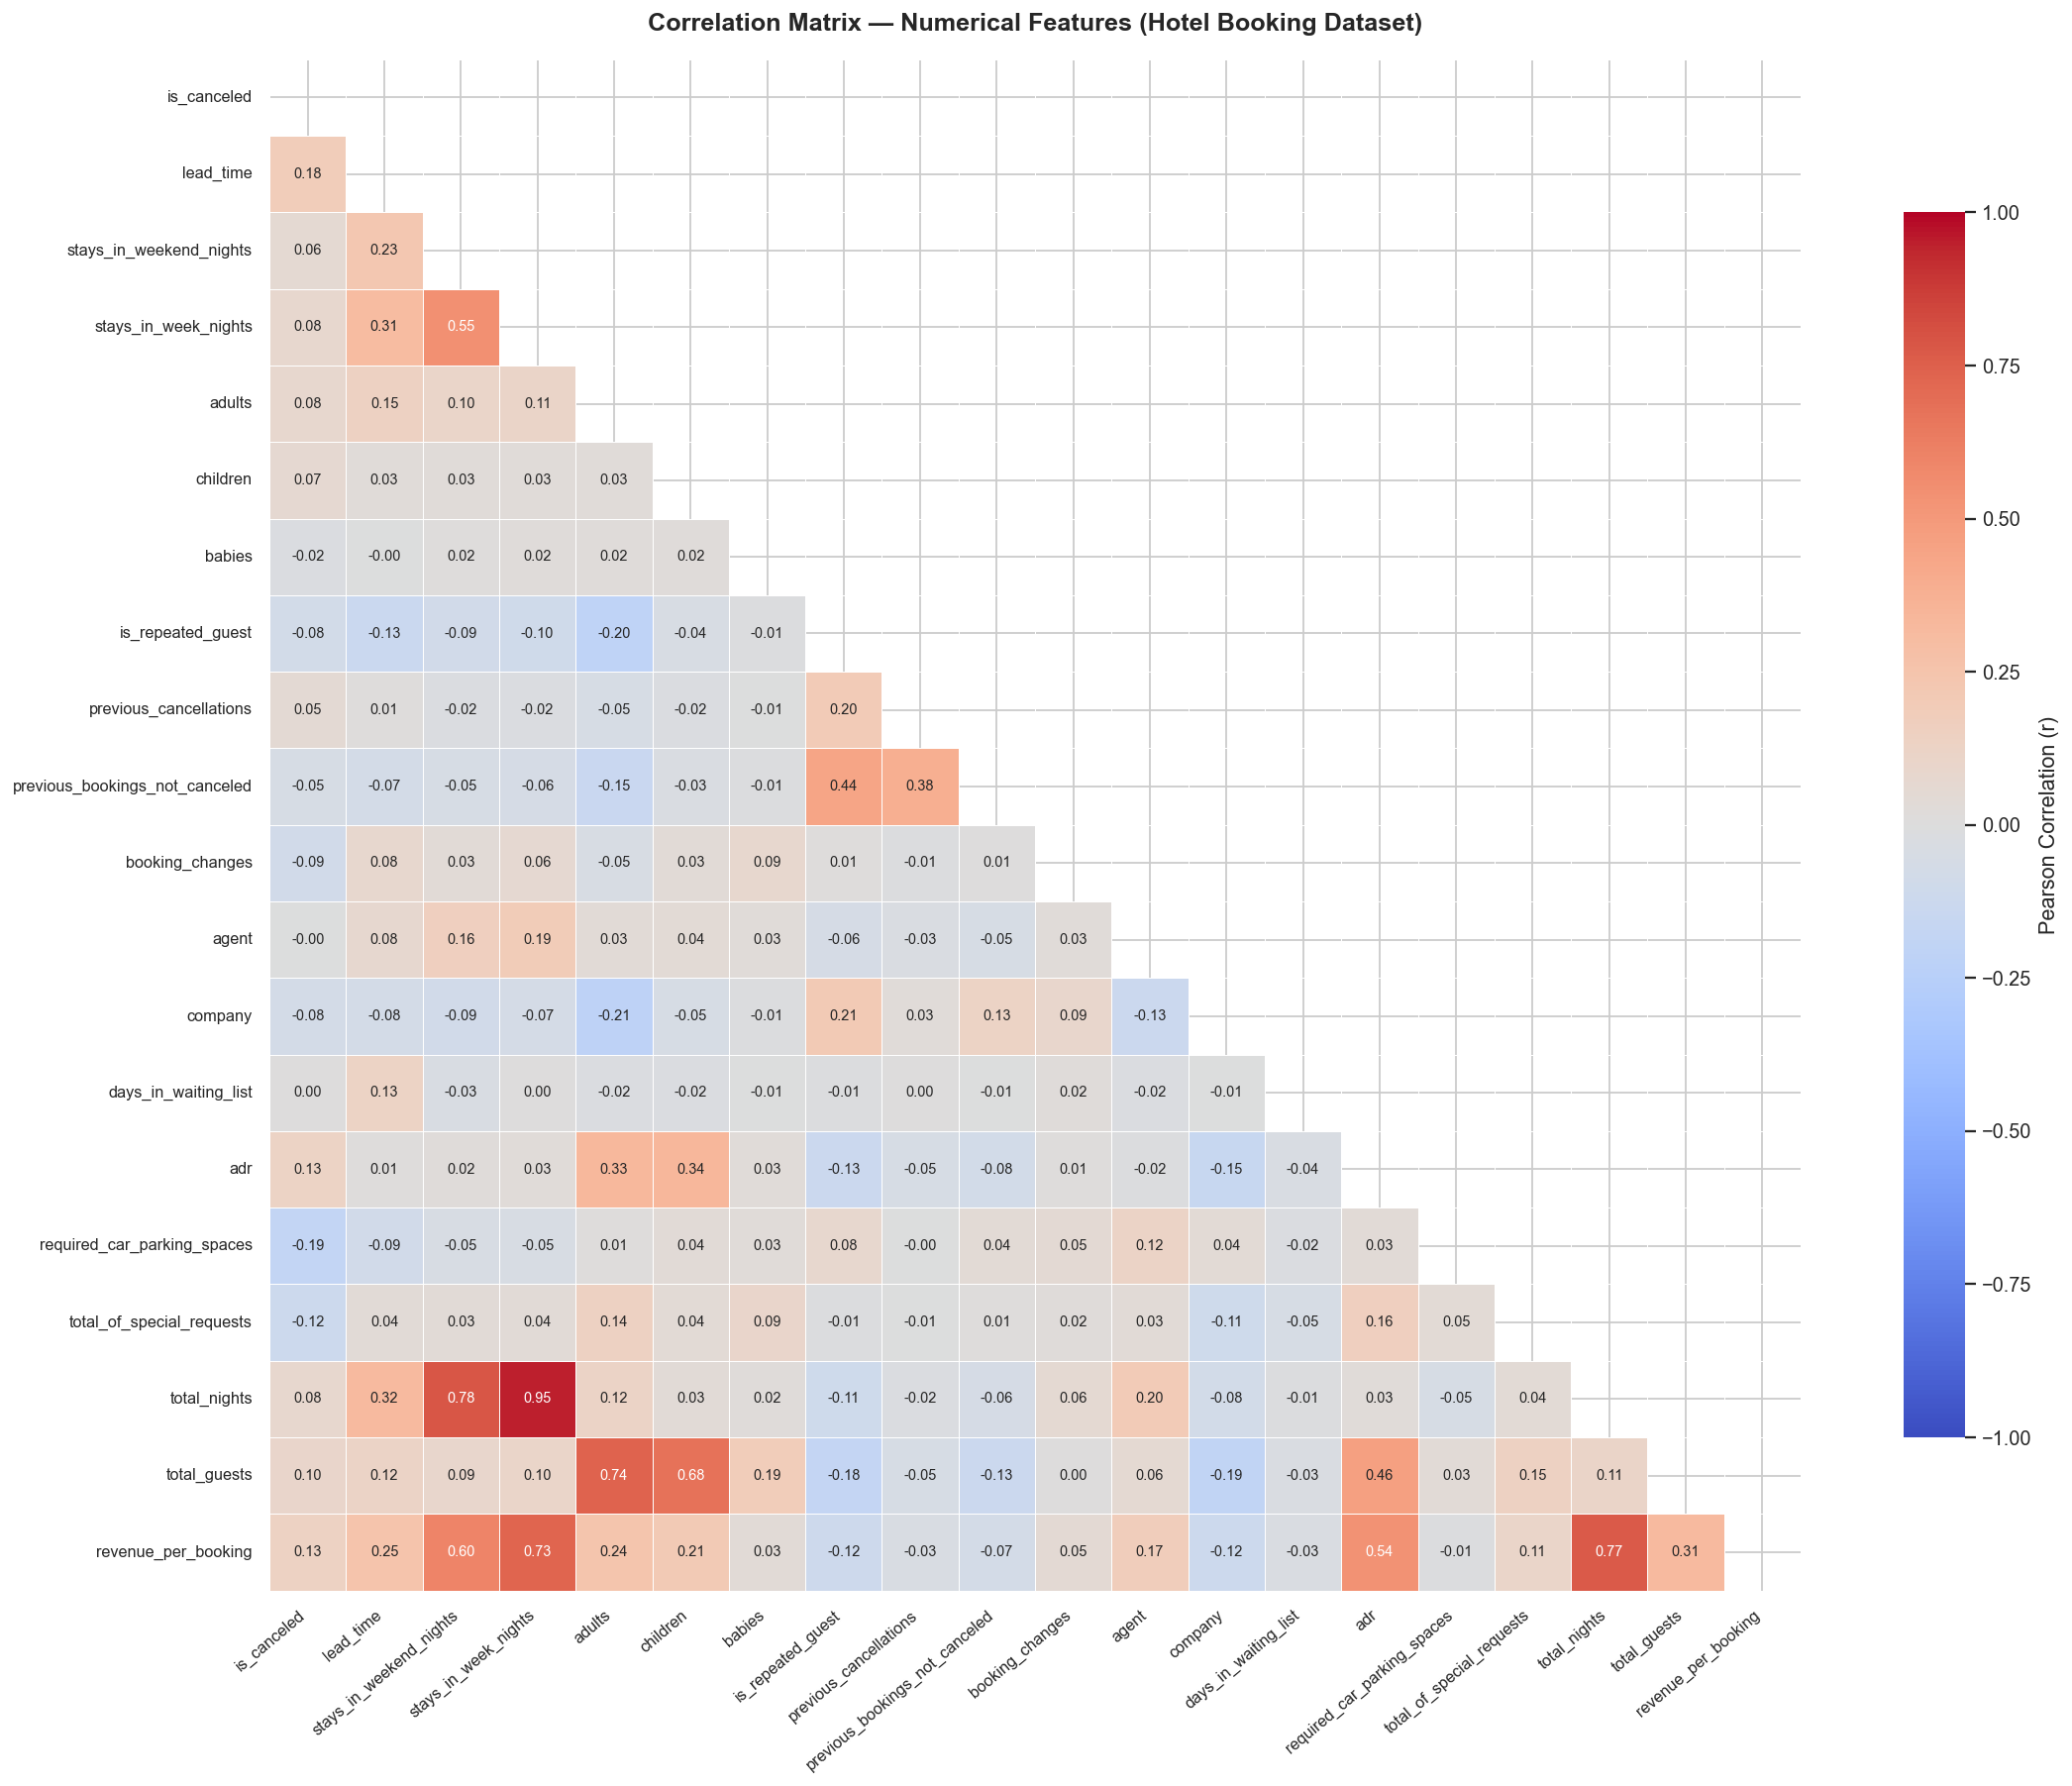

Saved -> visuals/correlation_heatmap_full.png


In [5]:
fig, ax = plt.subplots(figsize=(18, 14))

# Mask upper triangle — show only lower triangle to avoid redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"},
    square=True,
)

ax.set_title("Correlation Matrix — Numerical Features (Hotel Booking Dataset)",
             fontsize=14, fontweight="bold", pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("../visuals/correlation_heatmap_full.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/correlation_heatmap_full.png")


---
## 4 — Correlations with `is_canceled`

In [6]:
cancel_corr = (
    corr_matrix["is_canceled"]
    .drop("is_canceled")
    .sort_values(key=abs, ascending=False)
    .round(4)
)

print("All features ranked by |correlation| with is_canceled:")
print()
print(f"  {'Feature':<40} {'Correlation':>12}  Direction")
print("  " + "-" * 62)
for feat, val in cancel_corr.items():
    direction = "positive (+)" if val > 0 else "negative (-)"
    strength  = ("STRONG" if abs(val) > 0.15
                 else "MODERATE" if abs(val) > 0.08
                 else "WEAK")
    print(f"  {feat:<40} {val:>12.4f}  {direction}  [{strength}]")


All features ranked by |correlation| with is_canceled:

  Feature                                   Correlation  Direction
  --------------------------------------------------------------
  required_car_parking_spaces                   -0.1865  negative (-)  [STRONG]
  lead_time                                      0.1827  positive (+)  [STRONG]
  revenue_per_booking                            0.1343  positive (+)  [MODERATE]
  adr                                            0.1272  positive (+)  [MODERATE]
  total_of_special_requests                     -0.1224  negative (-)  [MODERATE]
  total_guests                                   0.1001  positive (+)  [MODERATE]
  booking_changes                               -0.0927  negative (-)  [MODERATE]
  adults                                         0.0830  positive (+)  [MODERATE]
  is_repeated_guest                             -0.0822  negative (-)  [MODERATE]
  total_nights                                   0.0798  positive (+)  [WEAK]


### Top 5 Features Most Correlated with Cancellation

C:\Users\sneha\AppData\Local\Temp\ipykernel_21828\3643981843.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(top5.index, rotation=20, ha="right", fontsize=9)


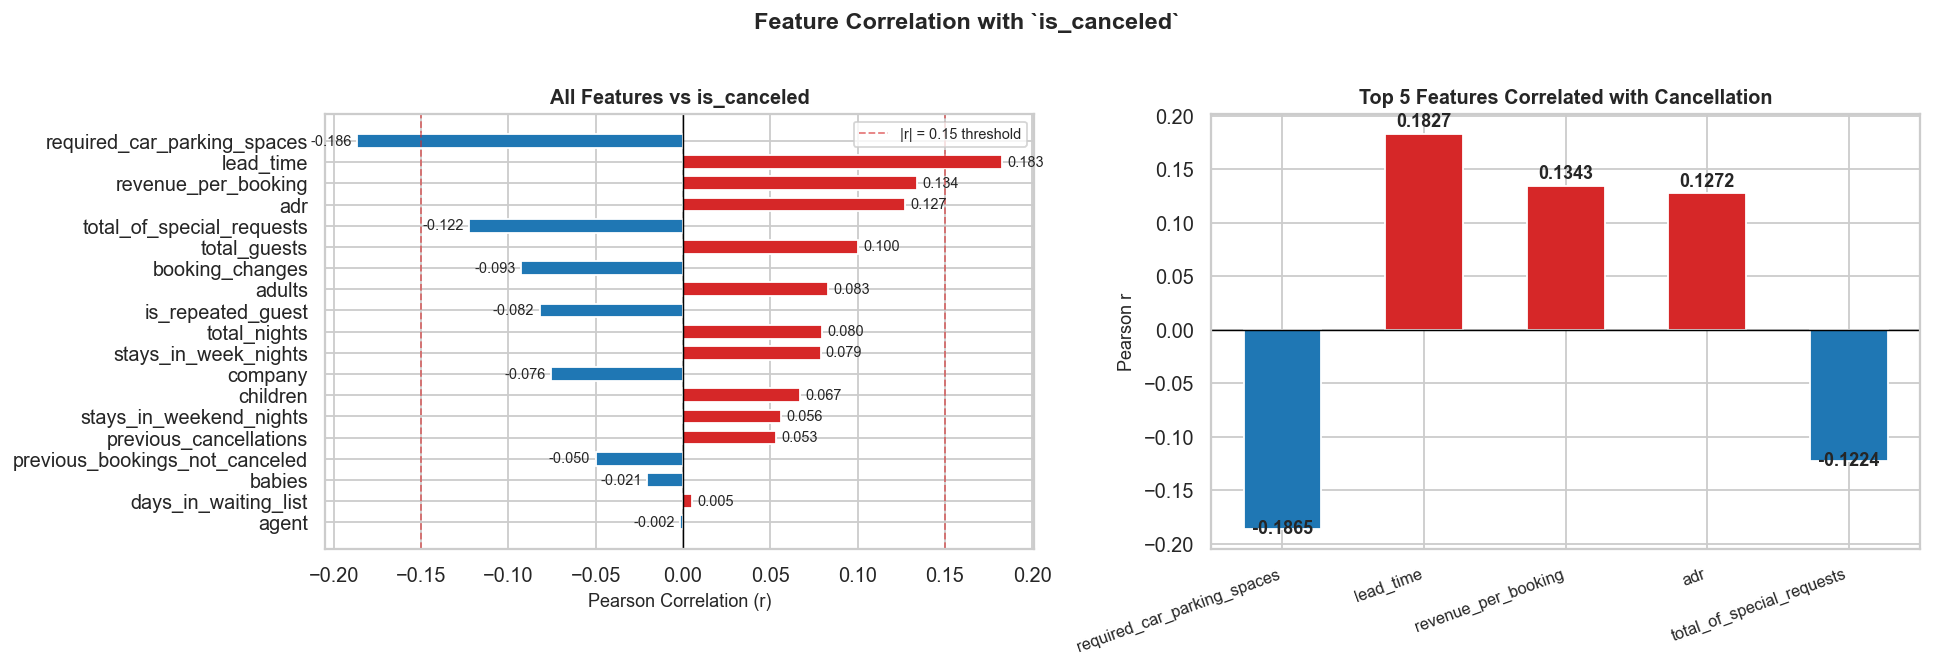

Saved -> visuals/cancellation_correlations.png


In [7]:
top5 = cancel_corr.head(5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Feature Correlation with `is_canceled`",
             fontsize=13, fontweight="bold", y=1.02)

# ── Plot 1: All correlations (horizontal bar) ────────────────────────────────
colors_all = ["#d62728" if v > 0 else "#1f77b4" for v in cancel_corr.values]
axes[0].barh(cancel_corr.index[::-1], cancel_corr.values[::-1],
             color=colors_all[::-1], edgecolor="white", height=0.65)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline( 0.15, color="#d62728", linestyle="--",
                linewidth=1, alpha=0.6, label="|r| = 0.15 threshold")
axes[0].axvline(-0.15, color="#d62728", linestyle="--", linewidth=1, alpha=0.6)
axes[0].set_title("All Features vs is_canceled", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Pearson Correlation (r)", fontsize=10)
axes[0].legend(fontsize=8)

for i, (feat, val) in enumerate(zip(cancel_corr.index[::-1],
                                     cancel_corr.values[::-1])):
    x_offset = 0.003 if val >= 0 else -0.003
    ha = "left" if val >= 0 else "right"
    axes[0].text(val + x_offset,
                 len(cancel_corr) - 1 - list(cancel_corr.index).index(feat),
                 f"{val:.3f}", va="center", ha=ha, fontsize=8)

# ── Plot 2: Top 5 spotlight ──────────────────────────────────────────────────
top5_colors = ["#d62728" if v > 0 else "#1f77b4" for v in top5.values]
bars = axes[1].bar(top5.index, top5.values.round(4),
                   color=top5_colors, edgecolor="white", width=0.55)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Top 5 Features Correlated with Cancellation",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Pearson r", fontsize=10)
axes[1].set_xticklabels(top5.index, rotation=20, ha="right", fontsize=9)

for bar, val in zip(bars, top5.values):
    y = bar.get_height() + 0.003 if val > 0 else bar.get_height() - 0.008
    axes[1].text(bar.get_x() + bar.get_width() / 2, y,
                 f"{val:.4f}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../visuals/cancellation_correlations.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/cancellation_correlations.png")


---
## 5 — Multicollinearity Check

In [8]:
# All unique pairs — upper triangle only
features = [c for c in analysis_cols if c != "is_canceled"]
pairs = []
for i, c1 in enumerate(features):
    for c2 in features[i+1:]:
        r = corr_matrix.loc[c1, c2]
        pairs.append({"feature_1": c1, "feature_2": c2, "correlation": round(r, 4)})

pairs_df = pd.DataFrame(pairs).sort_values("correlation", key=abs, ascending=False)

print("All feature pairs by |correlation| (top 15):")
print()
print(pairs_df.head(15).to_string(index=False))
print()

# Flag above thresholds
HIGH_THRESH  = 0.85
MOD_THRESH   = 0.70

high_mc  = pairs_df[pairs_df["correlation"].abs() > HIGH_THRESH]
mod_mc   = pairs_df[(pairs_df["correlation"].abs() > MOD_THRESH) &
                    (pairs_df["correlation"].abs() <= HIGH_THRESH)]

print("=" * 60)
print(f"  Pairs with |r| > {HIGH_THRESH} (HIGH multicollinearity risk):")
if len(high_mc):
    for _, row in high_mc.iterrows():
        print(f"    {row.feature_1}  x  {row.feature_2}  =  {row.correlation:.4f}  ⚠ DROP CANDIDATE")
else:
    print("    None")

print()
print(f"  Pairs with {MOD_THRESH} < |r| <= {HIGH_THRESH} (MODERATE — monitor):")
for _, row in mod_mc.iterrows():
    print(f"    {row.feature_1}  x  {row.feature_2}  =  {row.correlation:.4f}")
print("=" * 60)


All feature pairs by |correlation| (top 15):

              feature_1                      feature_2  correlation
   stays_in_week_nights                   total_nights       0.9492
stays_in_weekend_nights                   total_nights       0.7817
           total_nights            revenue_per_booking       0.7683
                 adults                   total_guests       0.7379
   stays_in_week_nights            revenue_per_booking       0.7293
               children                   total_guests       0.6753
stays_in_weekend_nights            revenue_per_booking       0.6004
stays_in_weekend_nights           stays_in_week_nights       0.5456
                    adr            revenue_per_booking       0.5360
                    adr                   total_guests       0.4645
      is_repeated_guest previous_bookings_not_canceled       0.4412
 previous_cancellations previous_bookings_not_canceled       0.3834
               children                            adr       0.3405
  

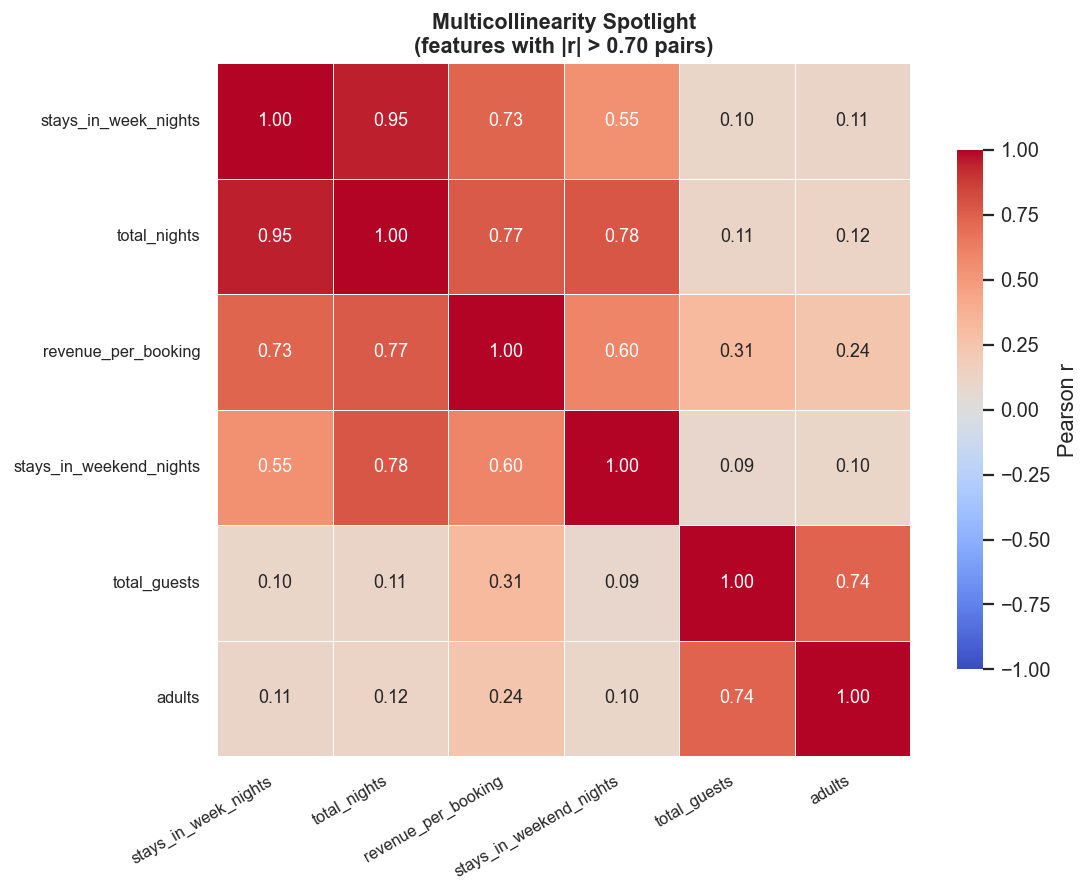

Saved -> visuals/multicollinearity_spotlight.png


In [9]:
# Focus heatmap on the features involved in high/moderate multicollinearity
flagged_features = list(set(
    list(high_mc["feature_1"]) + list(high_mc["feature_2"]) +
    list(mod_mc["feature_1"])  + list(mod_mc["feature_2"])
))

flagged_corr = corr_matrix.loc[flagged_features, flagged_features]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    flagged_corr, ax=ax,
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    square=True,
)
ax.set_title("Multicollinearity Spotlight\n(features with |r| > 0.70 pairs)",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("../visuals/multicollinearity_spotlight.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/multicollinearity_spotlight.png")


---
## 6 — Feature Selection Rationale & Plan for Modelling

### 6.1 Top 5 Features Most Correlated with `is_canceled`

| Rank | Feature | Correlation (r) | Direction | Interpretation |
|------|---------|----------------|-----------|---------------|
| 1 | `required_car_parking_spaces` | **−0.1865** | Negative | Guests requesting parking cancel far less — high intent signal |
| 2 | `lead_time` | **+0.1827** | Positive | Longer advance bookings cancel more (confirmed in Part 2) |
| 3 | `revenue_per_booking` | **+0.1343** | Positive | Higher-value bookings have modestly higher cancellation risk |
| 4 | `adr` | **+0.1272** | Positive | Higher-priced rooms cancel slightly more |
| 5 | `total_of_special_requests` | **−0.1224** | Negative | Guests who make requests are more committed and cancel less |

**Strongest signals:**

- **`required_car_parking_spaces` (r = −0.187):** The single strongest negative
  predictor. A guest who plans their parking is operationally committed to the stay.
  This is a high-quality, low-noise feature.

- **`lead_time` (r = +0.183):** Consistent with the lead-time bucket analysis — the
  further ahead a booking is made, the higher the cancellation risk.

- **`total_of_special_requests` (r = −0.122):** Special requests (extra pillows,
  specific floor, dietary requirements) signal genuine engagement with the stay.
  Guests making multiple requests rarely cancel.

**Note:** All correlations are modest (|r| < 0.20), which is typical for cancellation
prediction. Individual linear correlations are weak — the true predictive power will
come from **feature combinations** in a tree-based model (Random Forest / XGBoost),
which can capture non-linear interactions between `lead_time`, `deposit_type`,
`customer_type`, and `market_segment` that single correlations cannot.

---

### 6.2 Multicollinearity Findings

**🔴 HIGH risk pair (|r| > 0.85) — Action required:**

| Pair | r | Recommendation |
|------|---|---------------|
| `stays_in_week_nights` × `total_nights` | **0.9492** | **DROP `stays_in_week_nights`** — `total_nights` is the engineered composite and more interpretable. Keeping both introduces redundant signal and inflates variance in linear models. |

**🟠 MODERATE pairs (0.70 < |r| ≤ 0.85) — Monitor:**

| Pair | r | Recommendation |
|------|---|---------------|
| `stays_in_weekend_nights` × `total_nights` | 0.7817 | Drop `stays_in_weekend_nights` — also subsumed by `total_nights` |
| `adults` × `total_guests` | 0.7379 | Drop `adults` — `total_guests` is the richer composite |
| `revenue_per_booking` × `total_nights` | 0.7683 | Keep both — the correlation is structural (revenue = adr × nights) but `revenue_per_booking` adds independent value as a pricing proxy |
| `revenue_per_booking` × `stays_in_week_nights` | 0.7293 | Resolved by dropping `stays_in_week_nights` |

**Combined recommendation:** Drop `stays_in_week_nights`, `stays_in_weekend_nights`,
and `adults` — they are fully captured by the engineered `total_nights` and
`total_guests` columns with less noise and collinearity.

---

### 6.3 Final Feature Selection Plan for Week 3 ML Model

**✅ KEEP — Strong predictors, no multicollinearity issues:**

| Feature | Type | Rationale |
|---------|------|-----------|
| `lead_time` | Numeric | #2 correlated; non-linear threshold effects confirmed |
| `required_car_parking_spaces` | Numeric | #1 correlated; high-intent proxy |
| `total_of_special_requests` | Numeric | #5 correlated; engagement signal |
| `adr` | Numeric | Pricing signal; capped and clean |
| `total_nights` | Numeric (engineered) | Stay duration; replaces weekend/week night split |
| `total_guests` | Numeric (engineered) | Party size; replaces adults/children/babies |
| `is_repeated_guest` | Binary | Loyalty signal |
| `previous_cancellations` | Numeric | Historical behaviour |
| `booking_changes` | Numeric | Engagement / commitment signal |
| `days_in_waiting_list` | Numeric | Waitlist implies high demand context |

**✅ KEEP (encode first) — Categorical features with strong known signal:**

| Feature | Type | Encoding |
|---------|------|----------|
| `hotel` | Categorical | Binary: City=1, Resort=0 |
| `deposit_type` | Categorical | One-hot (3 categories) |
| `customer_type` | Categorical | One-hot (4 categories) |
| `market_segment` | Categorical | One-hot (7 categories) |
| `distribution_channel` | Categorical | One-hot (5 categories) |
| `arrival_date_month` | Categorical | Ordinal or cyclical encoding |

**❌ DROP before modelling:**

| Feature | Reason |
|---------|--------|
| `stays_in_week_nights` | HIGH multicollinearity with `total_nights` (r=0.95) |
| `stays_in_weekend_nights` | MODERATE multicollinearity with `total_nights` (r=0.78) |
| `adults` | MODERATE multicollinearity with `total_guests` (r=0.74) |
| `children`, `babies` | Subsumed by `total_guests` |
| `arrival_date` | Raw datetime — use `lead_time` and `arrival_date_month` instead |
| `reservation_status_date` | Post-booking — data leakage risk |
| `reservation_status` | Direct leakage: this IS the cancellation label |
| `agent`, `company` | Filled with 0 sentinel — very low correlation; noise risk |
| `arrival_date_year` | Removed earlier as date component; limited predictive value |

---

### 6.4 Notes on Linear Correlation Limits

Pearson correlations measure **linear** relationships only. Several key features known
to be predictive of cancellation show low linear |r| but will likely show strong
**non-linear importance** in tree-based models:

- `deposit_type` (categorical — cannot appear in correlation matrix but is known
  from Part 3 to have 94.7% cancellation for Non Refund)
- `customer_type` (Transient at 30.5% vs Group at 7.2%)
- `market_segment` and `distribution_channel`

The correlation matrix should be treated as a **necessary screening tool**
(catching multicollinearity) rather than a complete feature ranking.
The definitive feature importance ranking will come from the Random Forest
model in Week 3 using permutation importance or SHAP values.
